# cifar100 geometry filtering: resnet50 / dinov2, MLE / TwoNN / effective rank

эксперимент:
- датасет: **CIFAR100**
- эмбеддинги: **ResNet50**, доступен вариант **DINOv2**
- методы:
  - **MLE ID**
  - **TwoNN ID**
  - **effective rank**
  - **geom_combo**
  - **random**
- fractions:
  - **10%**
  - **40%**
  - **70%**
  - **100% full**
- downstream:
  - **ResNet18**
  - **ResNet50**

pipeline:
1. загрузка CIFAR100
2. извлечение эмбеддингов
3. вычисление geometry scores
4. отбор subset'ов
5. обучение downstream ResNet
6. scaling curves и итоговые таблицы


## config

по умолчанию:
- `embedder_name = "resnet50"`
- `downstream_arch = "resnet18"`

доступные варианты:
- `embedder_name`: `resnet50`, `dinov2_small`
- `downstream_arch`: `resnet18`, `resnet50`

ноутбук предназначен для сравнения **raw geometry selectors** на CIFAR100:
- `random`
- `effective_rank`
- `mle_id`
- `twonn_id`
- `geom_combo`
- `full`


In [1]:

import os
import math
import json
import time
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
import torchvision.models as tvm

from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors

try:
    import timm
    HAS_TIMM = True
except Exception:
    timm = None
    HAS_TIMM = False

@dataclass
class CFG:
    seed: int = 42
    seeds: tuple = (11, 22, 33)
    fractions: tuple = (0.10, 0.40, 0.70)
    run_methods: tuple = ("random", "effective_rank", "mle_id", "twonn_id", "geom_combo")
    embedder_name: str = "resnet50"
    downstream_arch: str = "resnet18"
    use_amp: bool = True
    val_size: int = 5000
    feature_batch_size: int = 128
    train_batch_size: int = 128
    eval_batch_size: int = 256
    num_workers: int = 2
    pca_dim: int = 64
    knn_k: int = 20
    er_k: int = 16
    epochs: int = 14
    lr: float = 0.1
    weight_decay: float = 5e-4
    momentum: float = 0.9
    label_smoothing: float = 0.0
    use_pretrained_downstream: bool = False
    train_full_baseline: bool = True
    cache_features: bool = True
    cache_scores: bool = True
    work_dir_name: str = "cifar100_geometry_filtering"

cfg = CFG()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IN_KAGGLE = os.path.exists("/kaggle")
BASE_DIR = Path("/kaggle/working" if IN_KAGGLE else ".") / cfg.work_dir_name
for sub in ["cache", "plots", "artifacts"]:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)
print("device:", DEVICE)
print("base_dir:", BASE_DIR)
print(asdict(cfg))

device: cuda
base_dir: /kaggle/working/cifar100_geometry_filtering
{'seed': 42, 'seeds': (11, 22, 33), 'fractions': (0.1, 0.4, 0.7), 'run_methods': ('random', 'effective_rank', 'mle_id', 'twonn_id', 'geom_combo'), 'embedder_name': 'resnet50', 'downstream_arch': 'resnet18', 'use_amp': True, 'val_size': 5000, 'feature_batch_size': 128, 'train_batch_size': 128, 'eval_batch_size': 256, 'num_workers': 2, 'pca_dim': 64, 'knn_k': 20, 'er_k': 16, 'epochs': 14, 'lr': 0.1, 'weight_decay': 0.0005, 'momentum': 0.9, 'label_smoothing': 0.0, 'use_pretrained_downstream': False, 'train_full_baseline': True, 'cache_features': True, 'cache_scores': True, 'work_dir_name': 'cifar100_geometry_filtering'}


In [2]:

CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def zscore(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    s = x.std()
    if s < eps:
        return np.zeros_like(x)
    return (x - x.mean()) / s

def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

class IndexedSubset(Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        real_i = int(self.indices[i])
        img, y = self.base_dataset[real_i]
        if self.transform is not None:
            img = self.transform(img)
        return img, int(y), real_i

def make_loader(dataset, batch_size, shuffle=False):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=cfg.num_workers, pin_memory=True, persistent_workers=cfg.num_workers > 0)

In [3]:

base_train = torchvision.datasets.CIFAR100(root=str(BASE_DIR / "artifacts"), train=True, download=True)
base_test = torchvision.datasets.CIFAR100(root=str(BASE_DIR / "artifacts"), train=False, download=True)
all_train_y = np.array(base_train.targets)
all_idx = np.arange(len(base_train))
train_idx, val_idx = train_test_split(all_idx, test_size=cfg.val_size, random_state=cfg.seed, stratify=all_train_y)
test_idx = np.arange(len(base_test))
print("train pool:", len(train_idx))
print("val:", len(val_idx))
print("test:", len(test_idx))
print("classes:", len(base_train.classes))

100%|██████████| 169M/169M [00:02<00:00, 65.2MB/s]


train pool: 45000
val: 5000
test: 10000
classes: 100


In [4]:

def build_resnet50_feature_extractor():
    weights = tvm.ResNet50_Weights.IMAGENET1K_V2
    model = tvm.resnet50(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)
    transform = weights.transforms()
    return model, transform

def build_dinov2_small_feature_extractor():
    if not HAS_TIMM:
        raise ImportError("timm is not installed; use embedder_name=\"resnet50\" or install timm")
    model_name = "vit_small_patch14_dinov2.lvd142m"
    model = timm.create_model(model_name, pretrained=True, num_classes=0)
    model.eval().to(DEVICE)
    data_config = timm.data.resolve_model_data_config(model)
    transform = timm.data.create_transform(**data_config, is_training=False)
    return model, transform

def build_feature_extractor(embedder_name):
    if embedder_name == "resnet50":
        return build_resnet50_feature_extractor()
    if embedder_name == "dinov2_small":
        return build_dinov2_small_feature_extractor()
    raise ValueError(f"unknown embedder_name={embedder_name}")

@torch.no_grad()
def extract_features(dataset, model, batch_size):
    loader = make_loader(dataset, batch_size=batch_size, shuffle=False)
    feats, ys, idxs = [], [], []
    for x, y, real_i in loader:
        x = x.to(DEVICE, non_blocking=True)
        out = model(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        feats.append(out.detach().float().cpu().numpy())
        ys.append(y.numpy())
        idxs.append(real_i.numpy())
    return np.concatenate(feats), np.concatenate(ys), np.concatenate(idxs)

embedder_model, embedder_transform = build_feature_extractor(cfg.embedder_name)
feature_cache = BASE_DIR / "cache" / f"features_{cfg.embedder_name}.npz"
if cfg.cache_features and feature_cache.exists():
    arr = np.load(feature_cache, allow_pickle=True)
    train_feats, train_y, train_real_idx = arr["train_feats"], arr["train_y"], arr["train_real_idx"]
    val_feats, val_y, val_real_idx = arr["val_feats"], arr["val_y"], arr["val_real_idx"]
    test_feats, test_y, test_real_idx = arr["test_feats"], arr["test_y"], arr["test_real_idx"]
else:
    train_feature_ds = IndexedSubset(base_train, train_idx, transform=embedder_transform)
    val_feature_ds = IndexedSubset(base_train, val_idx, transform=embedder_transform)
    test_feature_ds = IndexedSubset(base_test, test_idx, transform=embedder_transform)
    train_feats, train_y, train_real_idx = extract_features(train_feature_ds, embedder_model, cfg.feature_batch_size)
    val_feats, val_y, val_real_idx = extract_features(val_feature_ds, embedder_model, cfg.feature_batch_size)
    test_feats, test_y, test_real_idx = extract_features(test_feature_ds, embedder_model, cfg.feature_batch_size)
    if cfg.cache_features:
        np.savez_compressed(feature_cache, train_feats=train_feats, train_y=train_y, train_real_idx=train_real_idx, val_feats=val_feats, val_y=val_y, val_real_idx=val_real_idx, test_feats=test_feats, test_y=test_y, test_real_idx=test_real_idx)
print("feature shapes:", train_feats.shape, val_feats.shape, test_feats.shape)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


feature shapes: (45000, 2048) (5000, 2048) (10000, 2048)


In [5]:

def local_mle_id_from_dists(dists, eps=1e-12):
    rk = dists[:, -1][:, None]
    logs = np.log((rk + eps) / (dists[:, :-1] + eps))
    return 1.0 / np.maximum(logs.mean(axis=1), eps)

def local_twonn_id_proxy(dists, eps=1e-12):
    mu = (dists[:, 1] + eps) / (dists[:, 0] + eps)
    return 1.0 / np.maximum(np.log(mu + eps), eps)

def batched_effective_rank(x_red, knn_idx, k_local, batch_size=512):
    x_t = torch.from_numpy(x_red.astype(np.float32))
    out = np.zeros(len(x_red), dtype=np.float32)
    use_gpu = DEVICE.startswith("cuda")
    for start in range(0, len(x_red), batch_size):
        end = min(start + batch_size, len(x_red))
        idx = torch.from_numpy(knn_idx[start:end, :k_local]).long()
        neigh = x_t[idx]
        if use_gpu:
            neigh = neigh.to(DEVICE, non_blocking=True)
        neigh = neigh - neigh.mean(dim=1, keepdim=True)
        s = torch.linalg.svdvals(neigh)
        p = (s ** 2)
        p = p / (p.sum(dim=1, keepdim=True) + 1e-12)
        er = torch.exp(-(p * torch.log(p + 1e-12)).sum(dim=1))
        out[start:end] = er.detach().cpu().numpy()
        if use_gpu:
            torch.cuda.empty_cache()
    return out

score_cache = BASE_DIR / "cache" / f"scores_{cfg.embedder_name}.csv"
pca_cache = BASE_DIR / "cache" / f"pca_{cfg.embedder_name}.npz"
if cfg.cache_scores and score_cache.exists() and pca_cache.exists():
    score_df = pd.read_csv(score_cache)
    pca_arr = np.load(pca_cache)
    train_red, val_red, test_red = pca_arr["train_red"], pca_arr["val_red"], pca_arr["test_red"]
else:
    pca = PCA(n_components=min(cfg.pca_dim, train_feats.shape[1]), random_state=cfg.seed)
    train_red = pca.fit_transform(train_feats)
    val_red = pca.transform(val_feats)
    test_red = pca.transform(test_feats)
    nbrs = NearestNeighbors(n_neighbors=cfg.knn_k + 1, metric="euclidean", n_jobs=-1)
    nbrs.fit(train_red)
    dists, knn_idx = nbrs.kneighbors(train_red, return_distance=True)
    dists, knn_idx = dists[:, 1:], knn_idx[:, 1:]
    effective_rank = batched_effective_rank(train_red, knn_idx, k_local=cfg.er_k, batch_size=512)
    mle_id = local_mle_id_from_dists(dists[:, :cfg.knn_k])
    twonn_id = local_twonn_id_proxy(dists[:, :2])
    geom_combo = (zscore(np.log1p(np.clip(effective_rank, 0, None))) + zscore(np.log1p(np.clip(mle_id, 0, None))) + zscore(np.log1p(np.clip(twonn_id, 0, None)))) / 3.0
    nn_labels = train_y[knn_idx[:, :10]]
    knn_self_prob = (nn_labels == train_y[:, None]).mean(axis=1)
    score_df = pd.DataFrame({"row": np.arange(len(train_red)), "real_idx": train_real_idx, "label": train_y, "effective_rank": effective_rank, "mle_id": mle_id, "twonn_id": twonn_id, "geom_combo": geom_combo, "knn_self_prob": knn_self_prob})
    score_df.to_csv(score_cache, index=False)
    np.savez_compressed(pca_cache, train_red=train_red, val_red=val_red, test_red=test_red)
display(score_df.head())
print(score_df[["effective_rank", "mle_id", "twonn_id", "geom_combo", "knn_self_prob"]].describe().T)

,row,real_idx,label,effective_rank,mle_id,twonn_id,geom_combo,knn_self_prob
0,0,37384,93,10.610479,25.566010,70.564997,0.757408,0.1
1,1,46604,78,10.763211,19.786144,6.474345,0.055418,0.0
2,2,38280,85,11.869939,21.150197,16.798187,0.668015,0.5
3,3,872,22,8.308173,13.827356,18.081226,-0.939251,1.0
4,4,31221,85,10.107415,11.574312,9.959824,-0.528134,0.1


                  count          mean           std       min        25%  \
effective_rank  45000.0  1.036779e+01  9.364371e-01  5.188591   9.788931   
mle_id          45000.0  1.612365e+01  6.242980e+00  0.629889  11.632569   
twonn_id        45000.0  4.666254e+08  2.159575e+10  0.033767  11.048559   
geom_combo      45000.0 -4.273520e-16  7.174831e-01 -3.333707  -0.456727   
knn_self_prob   45000.0  4.617044e-01  3.430741e-01  0.000000   0.100000   

                      50%        75%           max  
effective_rank  10.467884  11.048083  1.297386e+01  
mle_id          15.361507  19.661675  7.224286e+01  
twonn_id        23.368533  57.322553  9.999111e+11  
geom_combo       0.038918   0.486248  6.538932e+00  
knn_self_prob    0.400000   0.800000  1.000000e+00  


In [6]:
sample_n = min(5000, len(train_red))
sub = train_red[np.random.RandomState(cfg.seed).choice(len(train_red), size=sample_n, replace=False)]

sub_k = min(cfg.knn_k + 1, len(sub))
sub_nbrs = NearestNeighbors(n_neighbors=sub_k, metric="euclidean", n_jobs=-1)
sub_nbrs.fit(sub)
sub_dists, _ = sub_nbrs.kneighbors(sub, return_distance=True)
sub_dists = sub_dists[:, 1:]

global_diag = {
    "twonn_global_dim_proxy_mean": float(np.mean(local_twonn_id_proxy(sub_dists[:, :2]))),
    "twonn_global_dim_proxy_median": float(np.median(local_twonn_id_proxy(sub_dists[:, :2]))),
    "mle_global_dim_mean": float(np.mean(local_mle_id_from_dists(sub_dists[:, :min(cfg.knn_k, sub_dists.shape[1])]))),
    "mle_global_dim_median": float(np.median(local_mle_id_from_dists(sub_dists[:, :min(cfg.knn_k, sub_dists.shape[1])]))),
}
print(global_diag)
save_json(global_diag, BASE_DIR / "artifacts" / f"global_id_diag_{cfg.embedder_name}.json")

{'twonn_global_dim_proxy_mean': 846.0659527863562, 'twonn_global_dim_proxy_median': 21.594931039451062, 'mle_global_dim_mean': 13.720408948609315, 'mle_global_dim_median': 13.0477374539911}


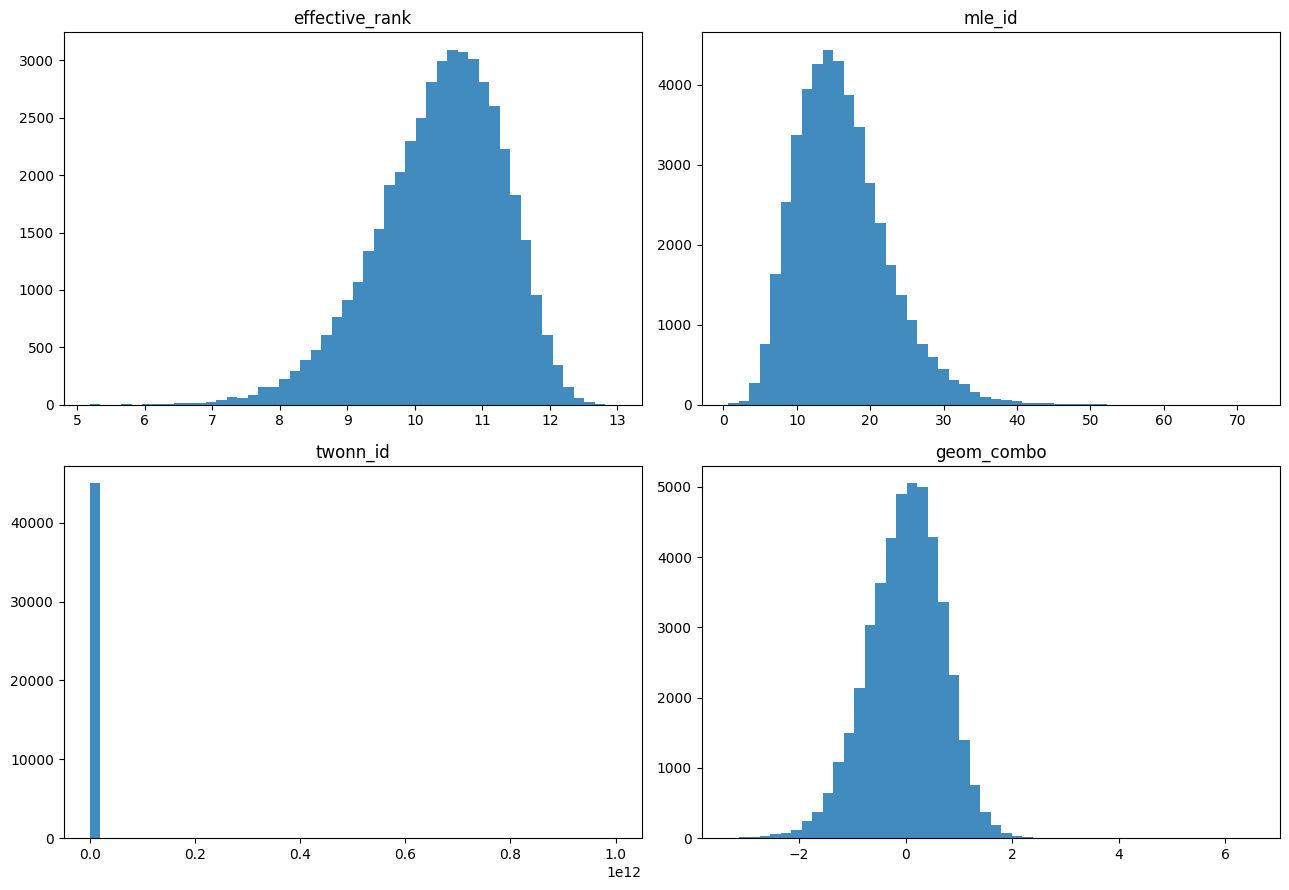

,effective_rank,mle_id,twonn_id,geom_combo,knn_self_prob
effective_rank,1.000,0.412,-0.007,0.716,-0.377
mle_id,0.412,1.000,-0.012,0.761,-0.469
twonn_id,-0.007,-0.012,1.000,0.163,0.016
geom_combo,0.716,0.761,0.163,1.000,-0.455
knn_self_prob,-0.377,-0.469,0.016,-0.455,1.000


In [7]:

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), ["effective_rank", "mle_id", "twonn_id", "geom_combo"]):
    ax.hist(score_df[col].values, bins=50, alpha=0.85)
    ax.set_title(col)
plt.tight_layout()
plt.show()

corr = score_df[["effective_rank", "mle_id", "twonn_id", "geom_combo", "knn_self_prob"]].corr()
display(corr.round(3))

In [8]:

METHOD_TO_SCORE = {"effective_rank": "effective_rank", "mle_id": "mle_id", "twonn_id": "twonn_id", "geom_combo": "geom_combo", "knn_confidence": "knn_self_prob"}

def select_balanced_random(labels, fraction, seed):
    rng = np.random.RandomState(seed)
    picked = []
    labels = np.asarray(labels)
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        n_take = max(1, int(round(len(idx) * fraction)))
        picked.append(rng.choice(idx, size=n_take, replace=False))
    return np.concatenate(picked)

def select_balanced_topk(labels, scores, fraction, seed, largest=True):
    rng = np.random.RandomState(seed)
    picked = []
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        n_take = max(1, int(round(len(idx) * fraction)))
        noise = rng.uniform(0.0, 1e-8, size=len(idx))
        order = np.argsort(scores[idx] + noise)
        if largest:
            order = order[::-1]
        picked.append(idx[order[:n_take]])
    return np.concatenate(picked)

def make_selection(method, fraction, seed):
    if method == "random":
        return select_balanced_random(score_df["label"].values, fraction, seed)
    if method in METHOD_TO_SCORE:
        return select_balanced_topk(score_df["label"].values, score_df[METHOD_TO_SCORE[method]].values, fraction, seed, largest=True)
    raise ValueError(method)

audit_rows = []
for frac in cfg.fractions:
    for method in cfg.run_methods:
        idx = make_selection(method, frac, cfg.seeds[0])
        sub = score_df.iloc[idx]
        audit_rows.append({"fraction": frac, "method": method, "n": len(idx), "effective_rank": sub["effective_rank"].mean(), "mle_id": sub["mle_id"].mean(), "twonn_id": sub["twonn_id"].mean(), "geom_combo": sub["geom_combo"].mean(), "knn_self_prob": sub["knn_self_prob"].mean()})
audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,fraction,method,n,effective_rank,mle_id,twonn_id,geom_combo,knn_self_prob
0,0.1,random,4500,10.361290,16.112165,2.222027e+08,-0.001411,0.463667
1,0.1,effective_rank,4500,11.623684,19.768337,2.222026e+08,0.653426,0.284422
2,0.1,mle_id,4500,10.755722,28.132049,2.070659e+02,0.800423,0.264933
3,0.1,twonn_id,4500,10.450532,18.212492,4.666254e+09,0.799326,0.416778
4,0.1,geom_combo,4500,11.120721,24.219334,4.666253e+09,1.107057,0.277133
5,0.4,random,18000,10.367896,16.164634,4.999558e+08,0.005080,0.462333
6,0.4,effective_rank,18000,11.119276,18.103338,2.222026e+08,0.394127,0.375800
7,0.4,mle_id,18000,10.638612,21.830038,2.222027e+08,0.474769,0.337167
8,0.4,twonn_id,18000,10.440951,17.756567,1.166563e+09,0.408545,0.426494
9,0.4,geom_combo,18000,10.867065,20.618824,1.166563e+09,0.611376,0.347178


In [9]:

train_tf = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(CIFAR100_MEAN, CIFAR100_STD)])
eval_tf = T.Compose([T.ToTensor(), T.Normalize(CIFAR100_MEAN, CIFAR100_STD)])

def build_downstream_model(name="resnet18", pretrained=False):
    if name == "resnet18":
        m = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    elif name == "resnet50":
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
    else:
        raise ValueError(name)
    new_conv = nn.Conv2d(m.conv1.in_channels, m.conv1.out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    with torch.no_grad():
        if pretrained:
            old_w = m.conv1.weight.data
            if old_w.shape[-1] == 7:
                new_conv.weight.copy_(old_w[:, :, 2:5, 2:5])
            else:
                new_conv.weight.copy_(old_w)
    m.conv1 = new_conv
    m.maxpool = nn.Identity()
    m.fc = nn.Linear(m.fc.in_features, 100)
    return m

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = 0.0
    n = 0
    correct = 0
    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        n += y.size(0)
    return {"loss": loss_sum / max(n, 1), "acc": correct / max(n, 1)}

def run_train(selected_pool_rows, seed):
    seed_everything(seed)
    selected_real_idx = train_real_idx[np.asarray(selected_pool_rows, dtype=np.int64)]
    train_ds = IndexedSubset(base_train, selected_real_idx, transform=train_tf)
    val_ds = IndexedSubset(base_train, val_idx, transform=eval_tf)
    test_ds = IndexedSubset(base_test, test_idx, transform=eval_tf)
    train_loader = make_loader(train_ds, batch_size=cfg.train_batch_size, shuffle=True)
    val_loader = make_loader(val_ds, batch_size=cfg.eval_batch_size, shuffle=False)
    test_loader = make_loader(test_ds, batch_size=cfg.eval_batch_size, shuffle=False)
    model = build_downstream_model(cfg.downstream_arch, pretrained=cfg.use_pretrained_downstream).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    optimizer = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and DEVICE.startswith("cuda")))
    best_val_acc = -1.0
    best_state = None
    hist = []
    for epoch in range(1, cfg.epochs + 1):
        model.train()
        loss_sum = 0.0
        n = 0
        correct = 0
        for x, y, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(cfg.use_amp and DEVICE.startswith("cuda"))):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(dim=1) == y).sum().item()
            n += y.size(0)
        scheduler.step()
        train_metrics = {"loss": loss_sum / max(n, 1), "acc": correct / max(n, 1)}
        val_metrics = evaluate(model, val_loader, criterion)
        hist.append({"epoch": epoch, "train_loss": train_metrics["loss"], "train_acc": train_metrics["acc"], "val_loss": val_metrics["loss"], "val_acc": val_metrics["acc"]})
        if val_metrics["acc"] > best_val_acc:
            best_val_acc = val_metrics["acc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch:02d} | train_acc={train_metrics['acc']:.4f} | val_acc={val_metrics['acc']:.4f}")
    model.load_state_dict(best_state)
    final_val = evaluate(model, val_loader, criterion)
    final_test = evaluate(model, test_loader, criterion)
    return {"best_val_acc": final_val["acc"], "best_val_loss": final_val["loss"], "test_acc_at_best_val": final_test["acc"], "test_loss_at_best_val": final_test["loss"], "history": hist}

In [10]:

results_path = BASE_DIR / "artifacts" / f"results_{cfg.embedder_name}_{cfg.downstream_arch}.csv"
history_dir = BASE_DIR / "artifacts" / "histories"
history_dir.mkdir(parents=True, exist_ok=True)
existing = pd.read_csv(results_path) if results_path.exists() else pd.DataFrame()
done_keys = set()
if len(existing) > 0:
    for _, r in existing.iterrows():
        done_keys.add((r["method"], float(r["fraction"]), int(r["seed"])))
rows = []
for seed in cfg.seeds:
    for fraction in cfg.fractions:
        for method in cfg.run_methods:
            key = (method, float(fraction), int(seed))
            if key in done_keys:
                print("skip done:", key)
                continue
            selected_rows = make_selection(method, fraction, seed)
            print("\nrun:", method, fraction, seed, "n=", len(selected_rows))
            out = run_train(selected_rows, seed)
            row = {"embedder": cfg.embedder_name, "downstream_arch": cfg.downstream_arch, "method": method, "fraction": fraction, "seed": seed, "n_selected": len(selected_rows), "best_val_acc": out["best_val_acc"], "best_val_loss": out["best_val_loss"], "test_acc_at_best_val": out["test_acc_at_best_val"], "test_loss_at_best_val": out["test_loss_at_best_val"]}
            rows.append(row)
            save_json(out["history"], history_dir / f"{method}__{fraction:.2f}__seed{seed}.json")
            pd.concat([existing, pd.DataFrame(rows)], ignore_index=True).to_csv(results_path, index=False)
if cfg.train_full_baseline:
    for seed in cfg.seeds:
        key = ("full", 1.0, int(seed))
        if key in done_keys:
            continue
        print("\nrun full:", seed)
        out = run_train(np.arange(len(train_idx)), seed)
        row = {"embedder": cfg.embedder_name, "downstream_arch": cfg.downstream_arch, "method": "full", "fraction": 1.0, "seed": seed, "n_selected": len(train_idx), "best_val_acc": out["best_val_acc"], "best_val_loss": out["best_val_loss"], "test_acc_at_best_val": out["test_acc_at_best_val"], "test_loss_at_best_val": out["test_loss_at_best_val"]}
        rows.append(row)
        save_json(out["history"], history_dir / f"full__1.00__seed{seed}.json")
        pd.concat([existing, pd.DataFrame(rows)], ignore_index=True).to_csv(results_path, index=False)
results_df = pd.read_csv(results_path)
display(results_df.sort_values(["fraction", "method", "seed"]))


run: random 0.1 11 n= 4500


/tmp/ipykernel_23/1969120459.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(cfg.use_amp and DEVICE.startswith("cuda")))
/tmp/ipykernel_23/1969120459.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(cfg.use_amp and DEVICE.startswith("cuda"))):


epoch 01 | train_acc=0.0256 | val_acc=0.0296
epoch 02 | train_acc=0.0491 | val_acc=0.0502
epoch 03 | train_acc=0.0642 | val_acc=0.0562
epoch 04 | train_acc=0.0860 | val_acc=0.0812
epoch 05 | train_acc=0.0956 | val_acc=0.0836
epoch 06 | train_acc=0.1153 | val_acc=0.0982
epoch 07 | train_acc=0.1380 | val_acc=0.1168
epoch 08 | train_acc=0.1518 | val_acc=0.1194
epoch 09 | train_acc=0.1802 | val_acc=0.1366
epoch 10 | train_acc=0.2011 | val_acc=0.1448
epoch 11 | train_acc=0.2291 | val_acc=0.1638
epoch 12 | train_acc=0.2509 | val_acc=0.1846
epoch 13 | train_acc=0.2778 | val_acc=0.1956
epoch 14 | train_acc=0.3098 | val_acc=0.1964

run: effective_rank 0.1 11 n= 4500
epoch 01 | train_acc=0.0233 | val_acc=0.0194
epoch 02 | train_acc=0.0487 | val_acc=0.0488
epoch 03 | train_acc=0.0656 | val_acc=0.0700
epoch 04 | train_acc=0.0793 | val_acc=0.0748
epoch 05 | train_acc=0.0976 | val_acc=0.0882
epoch 06 | train_acc=0.1149 | val_acc=0.0866
epoch 07 | train_acc=0.1238 | val_acc=0.1040
epoch 08 | train_ac

,embedder,downstream_arch,method,fraction,seed,n_selected,best_val_acc,best_val_loss,test_acc_at_best_val,test_loss_at_best_val
1,resnet50,resnet18,effective_rank,0.1,11,4500,0.1676,3.692725,0.1688,3.631959
16,resnet50,resnet18,effective_rank,0.1,22,4500,0.1666,3.716730,0.1672,3.671092
31,resnet50,resnet18,effective_rank,0.1,33,4500,0.1602,3.689292,0.1654,3.643787
4,resnet50,resnet18,geom_combo,0.1,11,4500,0.1708,3.547373,0.1672,3.545502
19,resnet50,resnet18,geom_combo,0.1,22,4500,0.1584,3.684146,0.1491,3.683488
34,resnet50,resnet18,geom_combo,0.1,33,4500,0.1792,3.530802,0.1745,3.532466
2,resnet50,resnet18,mle_id,0.1,11,4500,0.1622,3.611333,0.1649,3.599695
17,resnet50,resnet18,mle_id,0.1,22,4500,0.1694,3.611945,0.1712,3.596317
32,resnet50,resnet18,mle_id,0.1,33,4500,0.1528,3.627160,0.1525,3.619939
0,resnet50,resnet18,random,0.1,11,4500,0.1964,3.407954,0.2070,3.390286


,method,fraction,mean_val_acc,std_val_acc,mean_test_acc,std_test_acc,n_runs
10,random,0.1,0.2155,0.0176,0.2217,0.0205,3
13,twonn_id,0.1,0.2061,0.0116,0.2062,0.0146,3
4,geom_combo,0.1,0.1695,0.0105,0.1636,0.0131,3
0,effective_rank,0.1,0.1648,0.0040,0.1671,0.0017,3
7,mle_id,0.1,0.1615,0.0083,0.1629,0.0095,3
11,random,0.4,0.5219,0.0038,0.5276,0.0033,3
14,twonn_id,0.4,0.5146,0.0164,0.5155,0.0179,3
8,mle_id,0.4,0.4996,0.0028,0.5018,0.0042,3
1,effective_rank,0.4,0.4895,0.0047,0.4919,0.0052,3
5,geom_combo,0.4,0.4877,0.0099,0.4941,0.0070,3


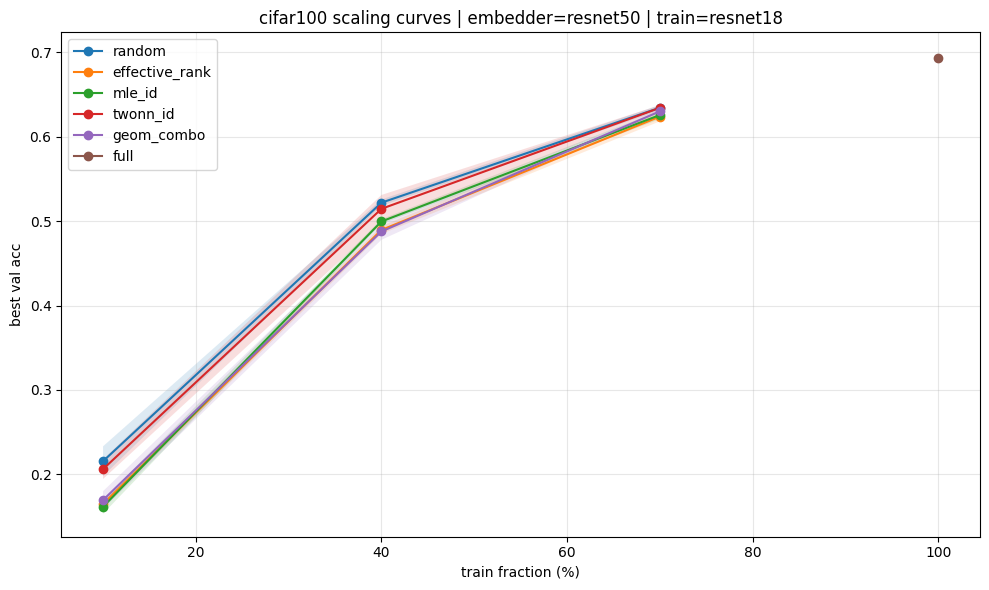

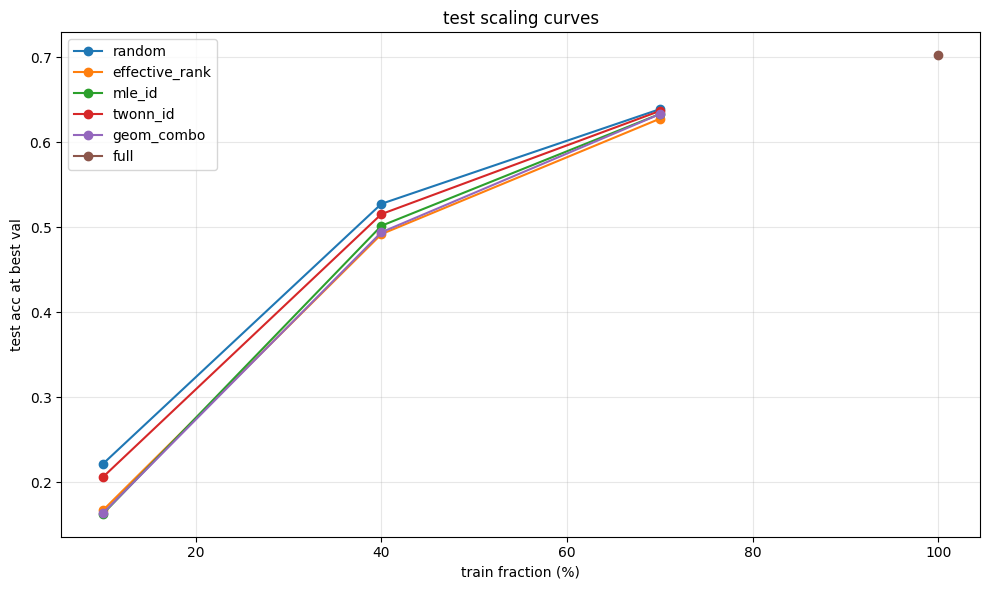

In [11]:

results_df = pd.read_csv(results_path)
summary = results_df.groupby(["method", "fraction"], as_index=False).agg(mean_val_acc=("best_val_acc", "mean"), std_val_acc=("best_val_acc", "std"), mean_test_acc=("test_acc_at_best_val", "mean"), std_test_acc=("test_acc_at_best_val", "std"), n_runs=("seed", "nunique"))
display(summary.sort_values(["fraction", "mean_val_acc"], ascending=[True, False]).round(4))
plot_methods = [m for m in list(cfg.run_methods) if m in set(results_df["method"])] + (["full"] if "full" in set(results_df["method"]) else [])
plt.figure(figsize=(10, 6))
for method in plot_methods:
    sub = summary[summary["method"] == method].sort_values("fraction")
    plt.plot(sub["fraction"] * 100, sub["mean_val_acc"], marker="o", label=method)
    std = sub["std_val_acc"].fillna(0)
    plt.fill_between(sub["fraction"] * 100, sub["mean_val_acc"] - std, sub["mean_val_acc"] + std, alpha=0.15)
plt.xlabel("train fraction (%)")
plt.ylabel("best val acc")
plt.title(f"cifar100 scaling curves | embedder={cfg.embedder_name} | train={cfg.downstream_arch}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_DIR / "plots" / f"scaling_curves_{cfg.embedder_name}_{cfg.downstream_arch}.png", dpi=180)
plt.show()

plt.figure(figsize=(10, 6))
for method in plot_methods:
    sub = summary[summary["method"] == method].sort_values("fraction")
    plt.plot(sub["fraction"] * 100, sub["mean_test_acc"], marker="o", label=method)
plt.xlabel("train fraction (%)")
plt.ylabel("test acc at best val")
plt.title("test scaling curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

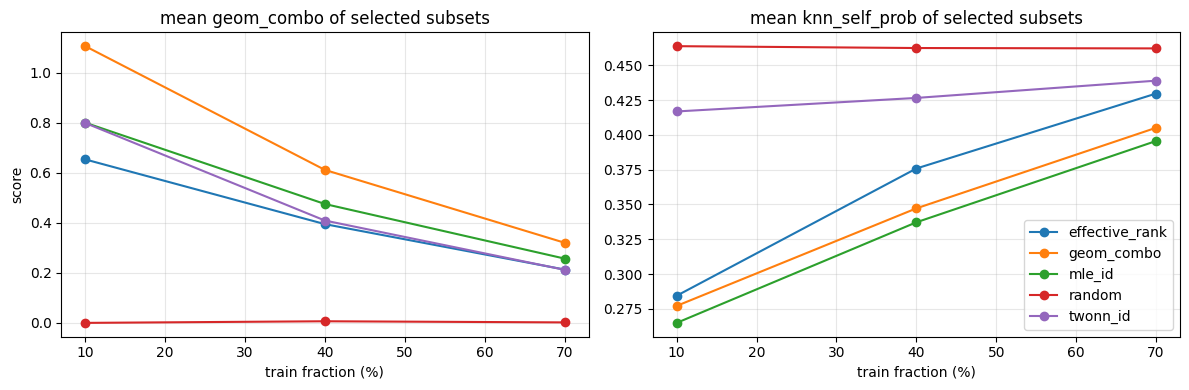

,fraction,method,mean_er,mean_mle,mean_twonn,mean_geom_combo,mean_knn_conf
0,0.1,random,10.3613,16.1122,2.222027e+08,-0.0014,0.4637
1,0.1,effective_rank,11.6237,19.7683,2.222026e+08,0.6534,0.2844
2,0.1,mle_id,10.7557,28.1320,2.070659e+02,0.8004,0.2649
3,0.1,twonn_id,10.4505,18.2125,4.666254e+09,0.7993,0.4168
4,0.1,geom_combo,11.1207,24.2193,4.666253e+09,1.1071,0.2771
5,0.4,random,10.3679,16.1646,4.999558e+08,0.0051,0.4623
6,0.4,effective_rank,11.1193,18.1033,2.222026e+08,0.3941,0.3758
7,0.4,mle_id,10.6386,21.8300,2.222027e+08,0.4748,0.3372
8,0.4,twonn_id,10.4410,17.7566,1.166563e+09,0.4085,0.4265
9,0.4,geom_combo,10.8671,20.6188,1.166563e+09,0.6114,0.3472


In [12]:

audit_rows = []
for frac in cfg.fractions:
    for method in cfg.run_methods:
        idx = make_selection(method, frac, cfg.seeds[0])
        sub = score_df.iloc[idx]
        audit_rows.append({"fraction": frac, "method": method, "mean_er": sub["effective_rank"].mean(), "mean_mle": sub["mle_id"].mean(), "mean_twonn": sub["twonn_id"].mean(), "mean_geom_combo": sub["geom_combo"].mean(), "mean_knn_conf": sub["knn_self_prob"].mean()})
audit_df = pd.DataFrame(audit_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pivot1 = audit_df.pivot(index="fraction", columns="method", values="mean_geom_combo")
pivot2 = audit_df.pivot(index="fraction", columns="method", values="mean_knn_conf")
for method in pivot1.columns:
    axes[0].plot(pivot1.index * 100, pivot1[method], marker="o", label=method)
for method in pivot2.columns:
    axes[1].plot(pivot2.index * 100, pivot2[method], marker="o", label=method)
axes[0].set_title("mean geom_combo of selected subsets")
axes[1].set_title("mean knn_self_prob of selected subsets")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel("train fraction (%)")
axes[0].set_ylabel("score")
axes[1].legend()
plt.tight_layout()
plt.show()
audit_df.to_csv(BASE_DIR / "artifacts" / f"selector_audit_{cfg.embedder_name}.csv", index=False)
display(audit_df.round(4))

## что менять если нужен более тяжелый прогон

- `cfg.embedder_name = "dinov2_small"` если хочешь selection по dinov2
- `cfg.downstream_arch = "resnet50"` если хочешь более тяжелую downstream модель
- `cfg.epochs = 20..30` если нужен более сильный финальный quality
- `cfg.run_methods` можно сократить для быстрого smoke test
- `cfg.seeds = (11,)` для быстрой проверки